Langgraph functions 

In [1]:
def ask(question):
    return {"messages":f"question :{question}"}

def get_answer(answer):
    return {"messages":f"this is the question you asked :{answer}"}

In [2]:
from langgraph.graph import StateGraph,MessagesState,START,END

def mock_llm(state: MessagesState):
    return {"messages": [{"role": "ai", "content": "hello world"}]}


workflow=StateGraph(MessagesState)

workflow.add_node(ask,"ask")
workflow.add_node(get_answer,"get_answer")
workflow.add_edge("ask","get_answer")
workflow.set_entry_point("ask")
workflow.set_finish_point("get_answer")

app=workflow.compile()



d:\Learning\AI projects\Langchain_projects-Langchain_2\venv\Lib\site-packages\langchain_core\_api\deprecation.py:26: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [3]:
result=app.invoke({"messages":"where is my dog"})

In [4]:
result

{'messages': [HumanMessage(content='where is my dog', additional_kwargs={}, response_metadata={}, id='df03ae57-3551-471f-b3fd-166e860f6811'),
  HumanMessage(content="question :{'messages': [HumanMessage(content='where is my dog', additional_kwargs={}, response_metadata={}, id='df03ae57-3551-471f-b3fd-166e860f6811')]}", additional_kwargs={}, response_metadata={}, id='f6377ce4-cd20-4c4f-b5f0-5226984a684d'),
  HumanMessage(content='this is the question you asked :{\'messages\': [HumanMessage(content=\'where is my dog\', additional_kwargs={}, response_metadata={}, id=\'df03ae57-3551-471f-b3fd-166e860f6811\'), HumanMessage(content="question :{\'messages\': [HumanMessage(content=\'where is my dog\', additional_kwargs={}, response_metadata={}, id=\'df03ae57-3551-471f-b3fd-166e860f6811\')]}", additional_kwargs={}, response_metadata={}, id=\'f6377ce4-cd20-4c4f-b5f0-5226984a684d\')]}', additional_kwargs={}, response_metadata={}, id='f1e08c70-5de7-49b0-9023-53b7b955f45a')]}

In [5]:
for res in app.stream(result):
    for key,value in res.items():
        print(f"here is the output from {key}")
        print("____________")
        print(value)
        print("\n")

here is the output from ask
____________
{'messages': 'question :{\'messages\': [HumanMessage(content=\'where is my dog\', additional_kwargs={}, response_metadata={}, id=\'df03ae57-3551-471f-b3fd-166e860f6811\'), HumanMessage(content="question :{\'messages\': [HumanMessage(content=\'where is my dog\', additional_kwargs={}, response_metadata={}, id=\'df03ae57-3551-471f-b3fd-166e860f6811\')]}", additional_kwargs={}, response_metadata={}, id=\'f6377ce4-cd20-4c4f-b5f0-5226984a684d\'), HumanMessage(content=\'this is the question you asked :{\\\'messages\\\': [HumanMessage(content=\\\'where is my dog\\\', additional_kwargs={}, response_metadata={}, id=\\\'df03ae57-3551-471f-b3fd-166e860f6811\\\'), HumanMessage(content="question :{\\\'messages\\\': [HumanMessage(content=\\\'where is my dog\\\', additional_kwargs={}, response_metadata={}, id=\\\'df03ae57-3551-471f-b3fd-166e860f6811\\\')]}", additional_kwargs={}, response_metadata={}, id=\\\'f6377ce4-cd20-4c4f-b5f0-5226984a684d\\\')]}\', additi

In [6]:
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain_core.messages import HumanMessage, AIMessage

def ask(state: MessagesState):
    user_msg = state["messages"][-1].content
    return {
        "messages":f"question from ask: {user_msg}"    
    }

def get_answer(state: MessagesState):
    last_msg = state["messages"][-1].content
    return {
        "messages":f"question from get answer: {last_msg}"
    }

# def ask(state: MessagesState):
#     user_msg = state["messages"][-1].content
#     return {"messages": [HumanMessage(content=f"question: {user_msg}")]}

# def get_answer(state: MessagesState):
#     last_msg = state["messages"][-1].content
#     return {"messages": [AIMessage(content=f"this is the question you asked: {last_msg}")]}

workflow = StateGraph(MessagesState)

workflow.add_node("ask", ask)
workflow.add_node("get_answer", get_answer)

workflow.add_edge("ask", "get_answer")
workflow.set_entry_point("ask")
workflow.set_finish_point("get_answer")

app = workflow.compile()

result = app.invoke({
    "messages": [
        HumanMessage(content="where is my dog")
    ]
})


print(result["messages"])


[HumanMessage(content='where is my dog', additional_kwargs={}, response_metadata={}, id='b3be1971-26a3-497e-8b29-7338b2226a2d'), HumanMessage(content='question from ask: where is my dog', additional_kwargs={}, response_metadata={}, id='a2817665-162b-4d5d-b1e1-0ab4eee77841'), HumanMessage(content='question from get answer: question from ask: where is my dog', additional_kwargs={}, response_metadata={}, id='a70e9044-a58d-49f4-9f45-c721a6fd5370')]


In [7]:
print(result["messages"][-1].content)

question from get answer: question from ask: where is my dog


In [8]:
from typing import TypedDict,Literal
import random

In [9]:
class journeystate(TypedDict):
    current_loc:str

In [10]:
def coimbatore(state:journeystate)->journeystate:
    print("departed from coimbatore")
    return {"current_loc":"started from coimbatore"}

def tirupur(state:journeystate)->journeystate:
    print("departed from tirupur")
    return{"current_loc":"started from tirupur"}

def trichy(state:journeystate)->journeystate:
    print("departed from trichy")
    return{"current_loc":"started from trichy"}

def salem(state:journeystate)->journeystate:
    print("departed from salem")
    return{"current_loc":"started from salem"}

def chennai(state:journeystate)->journeystate:
    print("reached chennai")
    return{"current_loc":"reached chennai"}

In [11]:
def intermediateloc(state:journeystate)->Literal["salem","trichy"]:
    print(f"deciding to route.. last update {state['current_loc']}")
    if random.random() < 0.5:
        print("Route through salem")
        return "salem"
    else:
        print("Route through trichy")
        return "trichy"

In [12]:
workflow2 = StateGraph(journeystate)

workflow2.add_node("coimbatore", coimbatore)
workflow2.add_node("tirupur", tirupur)
workflow2.add_node("trichy",trichy)
workflow2.add_node("salem", salem)
workflow2.add_node("chennai", chennai)

workflow2.set_entry_point("coimbatore")
workflow2.add_edge("coimbatore", "tirupur")
workflow2.add_conditional_edges("tirupur",intermediateloc)
workflow2.add_edge("trichy", "chennai")
workflow2.add_edge("salem", "chennai")
workflow2.set_finish_point("chennai")

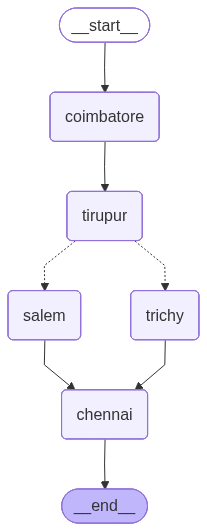

In [13]:
route=workflow2.compile()
route

In [14]:
route.invoke({"current_loc":"coimbatore"})

departed from coimbatore
departed from tirupur
deciding to route.. last update started from tirupur
Route through trichy
departed from trichy
reached chennai


{'current_loc': 'reached chennai'}

Tool Calling in langchain

In [15]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [16]:
from langchain_groq import ChatGroq

llm=ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0.3,
    max_tokens=None,
    max_retries=2
)

In [17]:
def multiply(a:int,b:int)->int:
    """this tool is used to multiple two numbers
    Args:
    a: first int
    b: second int

    """
    return a*b

In [18]:
tool_call_llm=llm.bind_tools([multiply])

In [19]:
response=tool_call_llm.invoke("what is 5 of 4")
response

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'a27ybtees', 'function': {'arguments': '{"a":5,"b":4}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 253, 'total_tokens': 272, 'completion_time': 0.039548647, 'completion_tokens_details': None, 'prompt_time': 0.016684893, 'prompt_tokens_details': None, 'queue_time': 0.050745457, 'total_time': 0.05623354}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_ff2b098aaf', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c3cf8-0aca-7fc2-8a33-ff3513c29818-0', tool_calls=[{'name': 'multiply', 'args': {'a': 5, 'b': 4}, 'id': 'a27ybtees', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 253, 'output_tokens': 19, 'total_tokens': 272})

In [20]:
response.tool_calls

[{'name': 'multiply',
  'args': {'a': 5, 'b': 4},
  'id': 'a27ybtees',
  'type': 'tool_call'}]

Tool call with langgraph

In [21]:
from langgraph.prebuilt import ToolNode,tools_condition

In [22]:
class sMessagesState(MessagesState):
    pass

In [23]:
def tool_call_with_llm(state:MessagesState):
    return {"messages":tool_call_llm.invoke(state["messages"])}

In [24]:
workflow3=StateGraph(MessagesState)
workflow3.add_node("tool_call_with_llm",tool_call_with_llm)
workflow3.add_node("tools",ToolNode([multiply]))
workflow3.add_edge(START,"tool_call_with_llm")
workflow3.add_conditional_edges("tool_call_with_llm",tools_condition)
workflow3.add_edge("tools",END)
request=workflow3.compile()


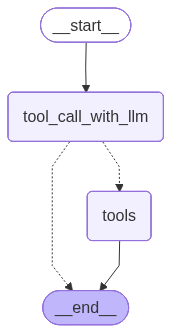

In [25]:
workflow3.compile()

In [48]:
output=request.invoke({"messages":[HumanMessage(content="what is 3 times of 2")]})
output

{'messages': [HumanMessage(content='what is 3 times of 2', additional_kwargs={}, response_metadata={}, id='227dfe42-117a-4bee-99c9-b8cb6f9c3a56'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'zcx8y247g', 'function': {'arguments': '{"a":3,"b":2}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 254, 'total_tokens': 273, 'completion_time': 0.04445997, 'completion_tokens_details': None, 'prompt_time': 0.018330062, 'prompt_tokens_details': None, 'queue_time': 0.047437368, 'total_time': 0.062790032}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_1151d4f23c', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c3cff-bea5-7720-a2d7-e819f940168f-0', tool_calls=[{'name': 'multiply', 'args': {'a': 3, 'b': 2}, 'id': 'zcx8y247g', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 254, 'output_t

In [49]:
for m in output['messages']:
    m.pretty_print()

================================ Human Message =================================

what is 3 times of 2
================================== Ai Message ==================================
Tool Calls:
  multiply (zcx8y247g)
 Call ID: zcx8y247g
  Args:
    a: 3
    b: 2
================================= Tool Message =================================
Name: multiply

6
